# Who is about to leave? Predicting customer churn for a subscription telecom

**UFCFMM — Business Intelligence and Data Mining · Portfolio (Group Project)**

Ibrahim Puri · 22038398 · BSc (Hons) Computer Science, UWE Bristol · Module Leader: Dr Kamran Soomro

*Submitted as an individual (group of one), so the group contribution document is omitted as per the brief.*

## 1. Problem definition and data scoping

**The business problem.** Subscription businesses live and die by retention: acquiring a telecom customer costs several times more than keeping one, and every leaver takes their whole future revenue stream with them. But retention budgets are finite — discounts are wasted unless aimed at people who were actually about to leave — which turns retention into a prediction problem. The question I set out to answer: **can we identify, from a customer's account and service profile, who is most likely to churn — accurately enough to target retention offers before they go?**

The costs here are asymmetric — missing a churner loses a whole revenue stream, while wrongly discounting a loyal customer only costs the discount — and any model has to be judged against that asymmetry, not raw accuracy. I return to this in Stage 4.

**The dataset.** I am using the IBM Telco Customer Churn dataset: 7,043 customers of a fictionalised (but realistically structured) telecom provider, with 21 attributes covering demographics (gender, senior citizen status, partner, dependents), subscribed services (phone, internet type, add-ons like online security and tech support), account information (tenure, contract type, payment method, monthly and total charges) and a binary churn label. It is publicly available via IBM's GitHub and Kaggle, and it fits the problem well: a genuine labelled business outcome rather than a proxy; a realistic mix of numeric and categorical attributes; enough rows (~7,000) to train and honestly evaluate a model while remaining fully explorable; and documentation good enough that every field can be read in business terms.

**Known limitations, stated up front.** The data is a single snapshot (no time dimension, so we can model *whether* churn happens but not *when*); it lacks usage and complaint data, which would likely be strong predictors in reality; and as an IBM sample, its revenue figures are illustrative. None of this prevents answering the question posed — it bounds the claims, and I flag each limit where it bites.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
RED, GREY = '#C0392B', '#7f8c8d'   # churn / no-churn colours used throughout
SEED = 42                          # fixed so every result in this notebook is reproducible

df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)
df.head(3)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Exploratory data analysis and pre-processing

Before modelling anything I want to know three things: how clean the data actually is, how imbalanced the target is, and which attributes visibly separate churners from stayers. The second point matters early because it decides how the models are trained and evaluated later.

In [2]:
# structure and data quality check
print(df.dtypes.value_counts(), '\n')
print('Duplicated customer IDs:', df['customerID'].duplicated().sum())
print('Missing values per column:', df.isna().sum().sum())

str        18
int64       2
float64     1
Name: count, dtype: int64 

Duplicated customer IDs: 0
Missing values per column: 0


On the face of it the dataset is clean — no nulls, no duplicate customers. But `TotalCharges` has been read in as a text column, which is a red flag: pandas only does that when something in it isn't numeric. Coercing it reveals the real problem.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blanks = df[df['TotalCharges'].isna()]
print(f'Rows with non-numeric TotalCharges: {len(blanks)}')
print('Their tenure values:', blanks['tenure'].unique())

Rows with non-numeric TotalCharges: 11
Their tenure values: [0]


All eleven problem rows have `tenure = 0` — brand-new customers not yet billed, whose total charges are genuinely zero but stored as a blank string. It's a small case study in why missing values need diagnosis, not reflexes: deletion would quietly remove the newest customers, and mean-imputation would hand a day-old customer thousands of dollars of billing history. Zero is the only treatment consistent with what the blank means.

In [4]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}  ({(df.Churn=="Yes").sum()} of {len(df)} customers)')

Overall churn rate: 26.5%  (1869 of 7043 customers)


So roughly **one customer in four churns (26.5%)**. The imbalance is mild but it matters: a useless model predicting "stays" for everyone scores 73.5% accuracy, which is why accuracy won't be my headline metric in Stage 4. Next — *who* is churning?

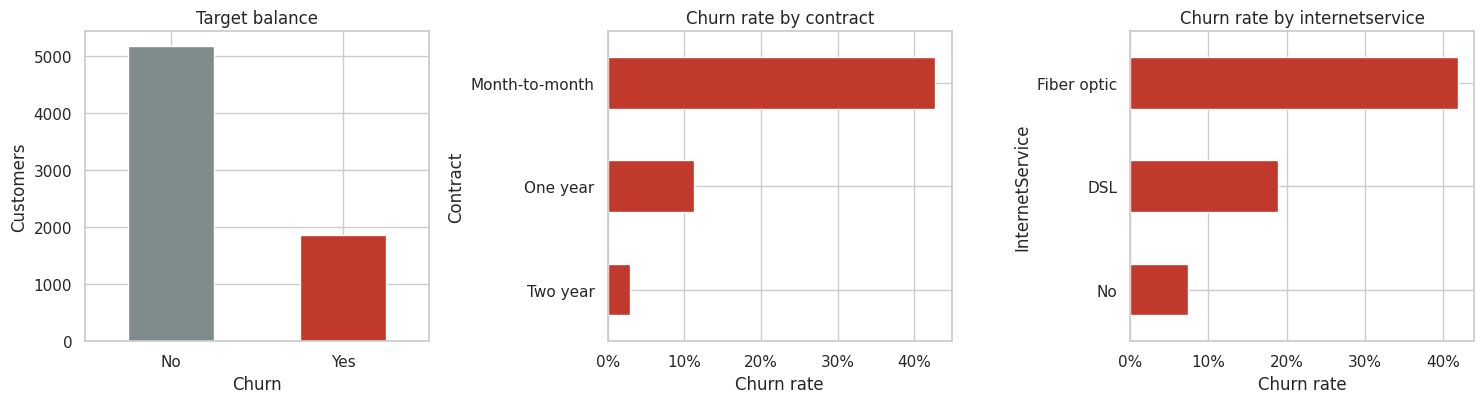

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

df['Churn'].value_counts().plot.bar(ax=axes[0], color=[GREY, RED], rot=0)
axes[0].set_title('Target balance'); axes[0].set_ylabel('Customers')

for ax, col in zip(axes[1:], ['Contract', 'InternetService']):
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values()
    rates.plot.barh(ax=ax, color=RED)
    ax.set_title(f'Churn rate by {col.lower()}')
    ax.set_xlabel('Churn rate')
    ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0%}')

plt.tight_layout()
plt.show()

Two commercially meaningful patterns jump out. **Contract type is the strongest single signal in the data**: month-to-month customers churn at 42.7%, against 11.3% on one-year and just 2.8% on two-year terms — a direct measure of how much loyalty commitment devices buy. More surprising: **fibre-optic customers churn at 41.9%, over double the DSL rate (19.0%)**. The premium product should be the sticky one; churning at twice the rate of the cheaper service suggests customers feel the price without feeling the quality — a service-experience problem, not a marketing one. I test whether the models agree in Stage 3.

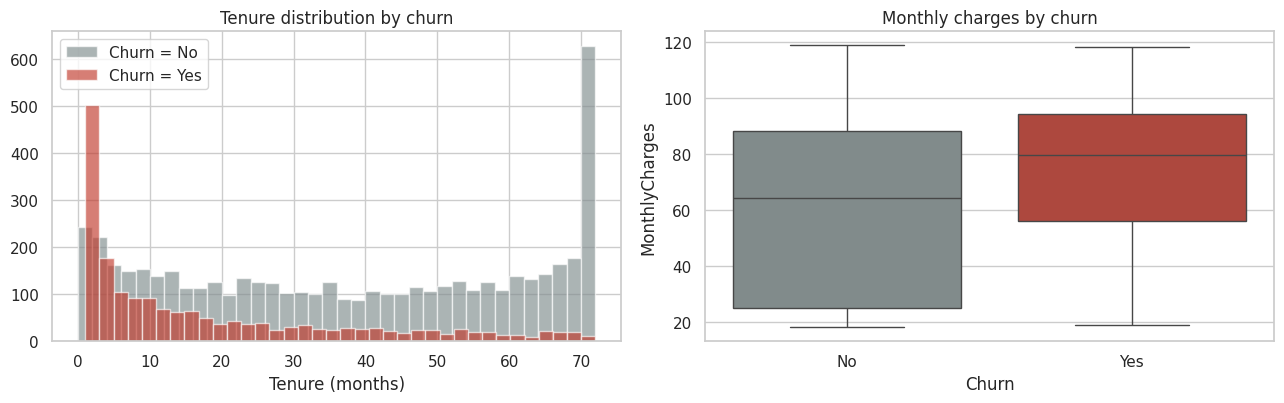

       tenure  MonthlyCharges
Churn                        
No       38.0           64.43
Yes      10.0           79.65


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for label, colour in [('No', GREY), ('Yes', RED)]:
    axes[0].hist(df.loc[df['Churn'] == label, 'tenure'], bins=36,
                 alpha=0.65, color=colour, label=f'Churn = {label}')
axes[0].set_title('Tenure distribution by churn'); axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette=[GREY, RED], legend=False, ax=axes[1])
axes[1].set_title('Monthly charges by churn')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')[['tenure', 'MonthlyCharges']].median().round(2))

The tenure histogram tells the sharpest story in the EDA: churn is overwhelmingly an **early-relationship event** — half of all churners leave within their first 10 months, while the median survivor has stayed 38, and the spike at very low tenure is essentially a picture of failed onboarding. Churners also pay more (median \$79.65/month vs \$64.43), consistent with the fibre finding: the likeliest leavers are the *expensive-plan, no-commitment* customers — exactly the segment where a save is worth the most.

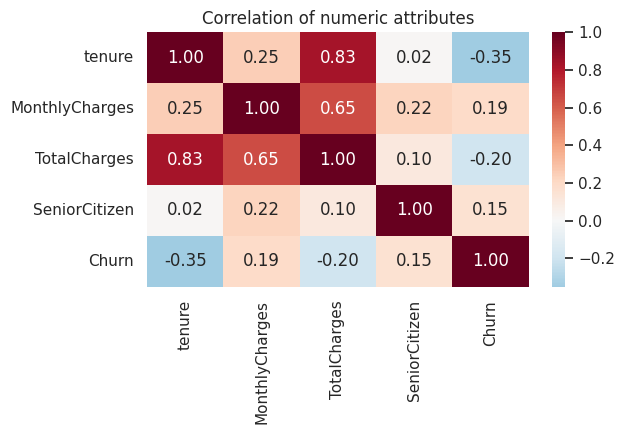

In [7]:
# numeric relationships — worth one quick check before encoding
numeric = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
numeric['Churn'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation of numeric attributes')
plt.tight_layout()
plt.show()

One thing to keep in mind for later: `TotalCharges` correlates 0.83 with tenure, which is arithmetic rather than insight (total ≈ tenure × monthly). I'm keeping the column because tree models handle redundancy fine, but it means individual logistic-regression coefficients on these three columns shouldn't be over-read — a caveat I return to when interpreting the model.

**Pre-processing decisions.** With the data understood, preparation is deliberately minimal and fully justified: drop `customerID` (an identifier carries no signal and would be a privacy liability in any exported model artefact); map the target to 1/0; one-hot encode the categorical columns with `drop_first=True` to avoid redundant dummy columns; and standardise the numeric features *inside a pipeline* for logistic regression only, so scaling is learned from training data alone and no information leaks from the test set. The split is 80/20 and **stratified**, keeping the 26.5% churn rate identical in both halves. For the class imbalance I use `class_weight='balanced'` rather than synthetic oversampling (SMOTE): with a 3:1 ratio, reweighting the loss achieves the same recall benefit without inventing artificial customers, keeps every evaluation honest on real data only, and is simpler to defend in production.

In [8]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop(columns=['customerID', 'Churn']), drop_first=True)
y = (df['Churn'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate — train {y_train.mean():.3f} | test {y_test.mean():.3f}')

Train: (5634, 30), Test: (1409, 30)
Churn rate — train 0.265 | test 0.265


## 3. Data mining: model selection, training and comparison

**Why classification, and why these three models.** The business question ("which customers will churn?") is a supervised binary classification problem with a labelled outcome, so classification is the natural technique — clustering or association rules would describe the customer base but couldn't rank individuals by risk, which is what the retention team needs. Rather than committing to one algorithm upfront, I compare three that occupy different points on the interpretability–flexibility spectrum:

**Logistic regression** — the industry baseline for churn; linear, fast, and its coefficients give directly explainable risk drivers. **Decision tree** (depth-capped at 5) — captures non-linear splits and interactions and produces rules a business user can read; the depth cap is there because an unconstrained tree memorises the training data. **Random forest** — an ensemble of trees that usually squeezes out more accuracy at the cost of transparency; it is here to test whether the extra complexity actually buys anything on this dataset.

Model selection uses **5-fold stratified cross-validation on the training set only**, scored by ROC-AUC. Cross-validation matters because a single split can flatter or punish a model by luck; AUC is the right selection metric because it measures ranking quality across *all* thresholds, and the business decision about which threshold to act on comes later, in Stage 4, where it belongs.

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                     random_state=SEED))]),
    'Decision tree (depth 5)': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=SEED),
    'Random forest (300 trees)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:<28} AUC = {scores.mean():.3f} ± {scores.std():.3f}')

Logistic regression          AUC = 0.846 ± 0.012


Decision tree (depth 5)      AUC = 0.824 ± 0.008


Random forest (300 trees)    AUC = 0.826 ± 0.013


An instructive result: **the simplest model wins**. Logistic regression scores 0.846 cross-validated AUC, ahead of the tree (0.824) and the forest (0.826) — 300 trees buy essentially nothing over one depth-5 tree. That's plausible rather than fluky: the EDA showed the dominant drivers (contract, tenure, service type) acting in largely additive, monotonic ways — exactly the structure a linear model captures — while the dataset is too small and clean for ensemble capacity to pay off. The best model is also the most interpretable, but I still evaluate all three on the held-out test set to check the ranking survives unseen data.

,ROC-AUC,Recall,Precision,F1,Accuracy
Model,,,,,
Logistic regression,0.841,0.786,0.507,0.616,0.740
Decision tree (depth 5),0.831,0.807,0.500,0.618,0.735
Random forest (300 trees),0.826,0.503,0.637,0.562,0.792


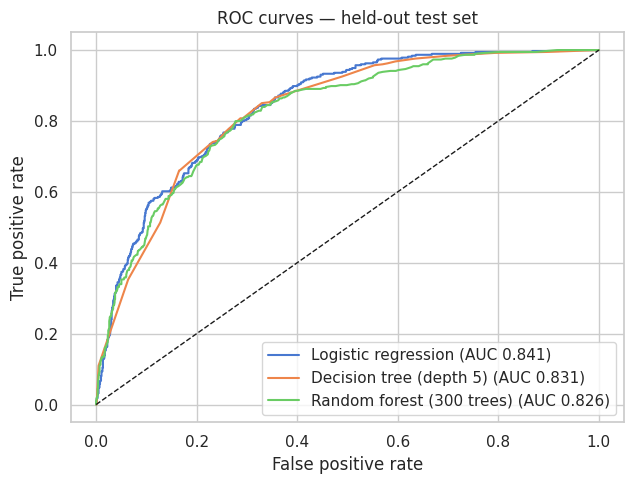

In [10]:
from sklearn.metrics import (roc_auc_score, roc_curve, recall_score,
                             precision_score, f1_score, accuracy_score)

test_summary, probs = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    probs[name] = p
    test_summary.append({'Model': name,
                         'ROC-AUC': roc_auc_score(y_test, p),
                         'Recall': recall_score(y_test, pred),
                         'Precision': precision_score(y_test, pred),
                         'F1': f1_score(y_test, pred),
                         'Accuracy': accuracy_score(y_test, pred)})

display(pd.DataFrame(test_summary).set_index('Model').round(3))

plt.figure(figsize=(6.5, 5))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC {roc_auc_score(y_test, p):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves — held-out test set'); plt.legend()
plt.tight_layout(); plt.show()

The test set confirms the ranking (logistic regression 0.841 AUC) with no sign of overfitting — test performance sits within one standard deviation of the cross-validated estimate. Note the random forest's profile: highest raw accuracy (79.2%) but recall of only 0.503, meaning it misses **half of all churners**. That is a textbook demonstration of why accuracy is the wrong headline metric for this problem — the forest earns its accuracy by being conservative about the minority class, which is precisely the class the business cares about. **Logistic regression, with balanced class weights, is the selected model**: best AUC, 78.6% recall, and full interpretability.

## 4. Evaluation

### 4.1 Technical evaluation

**Justifying the metrics.** The costs of the two error types are asymmetric. A false negative (missed churner) costs the customer's whole future revenue; a false positive (offering a discount to someone who was staying) costs only the offer. So the primary metrics are **recall** on the churn class (how many leavers we catch), **precision** (how much of the retention budget lands on real churners), and **ROC-AUC** for threshold-free ranking quality. Accuracy is reported but explicitly demoted, for the reason the random forest just demonstrated.

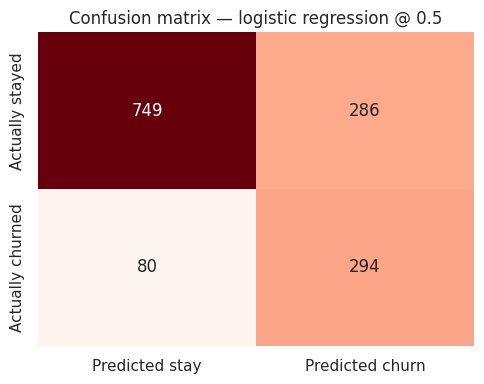

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [11]:
from sklearn.metrics import confusion_matrix, classification_report

final_model = models['Logistic regression']
p_test = probs['Logistic regression']
pred_05 = (p_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_05)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted stay', 'Predicted churn'],
            yticklabels=['Actually stayed', 'Actually churned'])
ax.set_title('Confusion matrix — logistic regression @ 0.5')
plt.tight_layout(); plt.show()

print(classification_report(y_test, pred_05, target_names=['Stayed', 'Churned']))

At the default 0.5 threshold the model catches **294 of the 374 churners (78.6%)** in the test set, missing 80. The price is 286 false alarms, giving churn-class precision of 0.507 — about half of the customers we'd contact were going to stay anyway. Whether that trade is good depends entirely on offer economics, so the threshold should be a *business* decision, not a software default. The curve below makes the trade-off explicit: management can slide along it depending on how much retention budget is available in a given quarter.

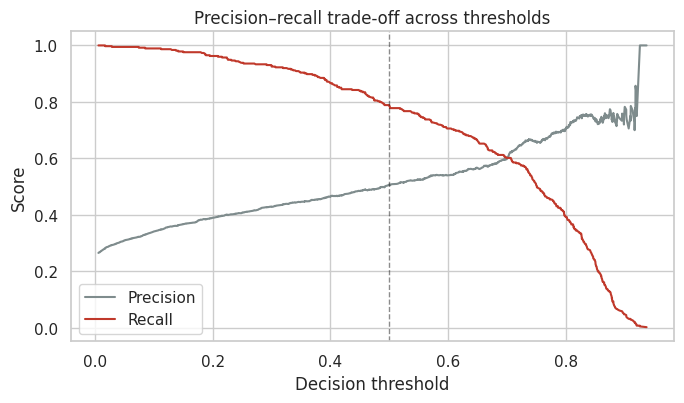

In [12]:
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, p_test)

plt.figure(figsize=(7, 4.2))
plt.plot(thresholds, prec[:-1], label='Precision', color=GREY)
plt.plot(thresholds, rec[:-1], label='Recall', color=RED)
plt.axvline(0.5, ls='--', lw=1, color='k', alpha=0.5)
plt.xlabel('Decision threshold'); plt.ylabel('Score')
plt.title('Precision–recall trade-off across thresholds')
plt.legend(); plt.tight_layout(); plt.show()

**What drives the predictions.** Because the chosen model is linear, its coefficients double as an explanation — a genuine advantage when the output has to persuade a marketing director rather than a data scientist.

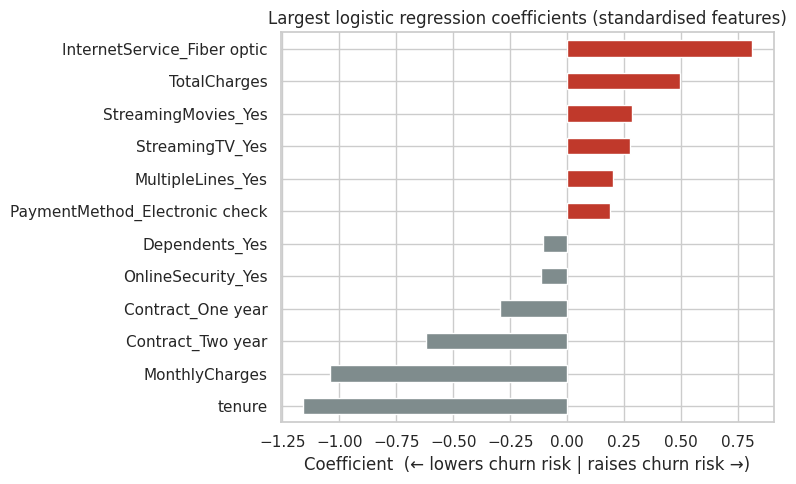

In [13]:
coefs = pd.Series(final_model.named_steps['model'].coef_[0],
                  index=X.columns).sort_values()
top = pd.concat([coefs.head(6), coefs.tail(6)])

plt.figure(figsize=(8, 5))
top.plot.barh(color=[GREY if v < 0 else RED for v in top])
plt.title('Largest logistic regression coefficients (standardised features)')
plt.xlabel('Coefficient  (← lowers churn risk | raises churn risk →)')
plt.tight_layout(); plt.show()

The model has independently rediscovered — and quantified — every pattern from the EDA. **Tenure is the strongest protective factor** and **fibre-optic internet the strongest risk factor**, with two-year contracts close behind on the protective side. Two honest caveats: the counter-intuitive signs on `MonthlyCharges` (negative) and `TotalCharges` (positive) are an artefact of the multicollinearity flagged in Stage 2 — those three columns partially encode each other, so their individual coefficients are not separately interpretable even though the model's *predictions* are unaffected. And these are correlations conditioned on the other features, not proven causes: the fibre coefficient justifies investigating the fibre experience, not blaming it outright.

### 4.2 Business evaluation and strategic recommendations

A risk score only creates value when it changes who the retention team contacts. The gains analysis below asks the operational question directly: *if we can only afford to contact a fraction of the customer base, how many of the real churners does the model put in front of us?*

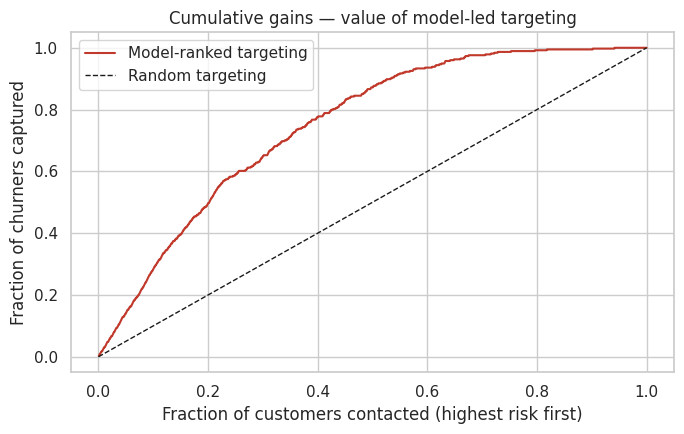

Top 10% riskiest: capture 28.1% of churners | precision 75.0%
Top 20% riskiest: capture 49.5% of churners | precision 65.8%
Top 30% riskiest: capture 64.7% of churners | precision 57.3%


In [14]:
ranked = pd.DataFrame({'p': p_test, 'churned': y_test.values}) \
           .sort_values('p', ascending=False).reset_index(drop=True)
ranked['cum_capture'] = ranked['churned'].cumsum() / ranked['churned'].sum()
ranked['frac_contacted'] = (ranked.index + 1) / len(ranked)

plt.figure(figsize=(7, 4.5))
plt.plot(ranked['frac_contacted'], ranked['cum_capture'], color=RED,
         label='Model-ranked targeting')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random targeting')
plt.xlabel('Fraction of customers contacted (highest risk first)')
plt.ylabel('Fraction of churners captured')
plt.title('Cumulative gains — value of model-led targeting')
plt.legend(); plt.tight_layout(); plt.show()

for frac in (0.10, 0.20, 0.30):
    top_n = ranked.head(int(len(ranked) * frac))
    print(f'Top {frac:.0%} riskiest: capture {top_n.churned.sum()/ranked.churned.sum():.1%} '
          f'of churners | precision {top_n.churned.mean():.1%}')

Contacting just the **top 20% of customers by model risk reaches ~50% of all churners, with two-thirds of contacts being genuine churn risks** — against 26.5% under random targeting. That is the model's value in one sentence: the same retention budget works roughly 2.5× harder.

**An illustrative ROI model.** To turn that into money I make three explicit assumptions, each conservative and each adjustable: a retention offer costs \$40 per contacted customer; offers save 30% of the genuine churners they reach (mid-range for telecom retention campaigns); and a saved churner retains 12 further months at the churner median of ~\$80/month. These are stated assumptions, not findings — the point of the calculation is the *shape* of the economics, and the code below makes every assumption a variable the business can change.

In [15]:
OFFER_COST, SAVE_RATE, MONTHS_RETAINED, ARPU = 40, 0.30, 12, 80

targeted = ranked.head(int(len(ranked) * 0.20))
n_contacted   = len(targeted)
true_churners = int(targeted['churned'].sum())
saved         = true_churners * SAVE_RATE

campaign_cost   = n_contacted * OFFER_COST
revenue_retained = saved * MONTHS_RETAINED * ARPU

print(f'Contacted: {n_contacted} | genuine churners reached: {true_churners}')
print(f'Expected saves: {saved:.0f} customers')
print(f'Campaign cost:      ${campaign_cost:,.0f}')
print(f'Revenue retained:   ${revenue_retained:,.0f}')
print(f'Return per $1 spent: ${revenue_retained / campaign_cost:.2f}')

Contacted: 281 | genuine churners reached: 185
Expected saves: 56 customers
Campaign cost:      $11,240
Revenue retained:   $53,280
Return per $1 spent: $4.74


On the test set alone (a fifth of the customer base), a top-20% campaign costs about \$11k and retains roughly \$53k of revenue — around **\$4.70 back per dollar spent** under deliberately cautious assumptions, before any margin adjustment. Scaled to the full base the effect is proportionally larger, and the return stays positive even if the save rate is halved.

**Strategic recommendations.** Four actions follow directly from the analysis. *First*, score the base monthly and aim retention offers at the top two risk deciles — the gains curve is the business case. *Second*, attack the contract lever: month-to-month customers churn at 15× the two-year rate, so migration incentives to annual terms turn the strongest risk factor into a durable fix rather than a repeated rescue. *Third*, treat fibre as a product problem: a premium service churning at 42% is leaking exactly the high-ARPU customers most valuable to save, and no coupon fixes service quality. *Fourth*, build a first-90-days onboarding programme — churn is front-loaded, so the cheapest save happens before the habit of leaving forms.

**Limitations and next steps.** The snapshot data cannot say *when* a customer will leave (a survival-analysis extension would); usage and complaints data would likely raise AUC materially; the ROI figures inherit their assumptions; and before deployment the model needs monitoring for drift and a periodic retraining schedule. None of these undermine the core conclusion — they define the sensible second iteration.

### 4.3 Ethical, privacy and security evaluation

A churn model looks ethically bland next to, say, credit scoring — nobody is denied a loan. But "who gets offered a discount" is still an automated decision that distributes money across customers, and this dataset contains two protected characteristics (gender, senior-citizen status). Rather than discussing bias hypothetically, I audit the deployed model directly: the fairness question is not whether the *dataset* looks balanced but whether the *model's errors* fall evenly.

In [16]:
groups = df.loc[X_test.index, ['gender', 'SeniorCitizen']].copy()
groups['y'], groups['pred'] = y_test.values, pred_05

def group_rates(frame, col):
    rows = []
    for g, sub in frame.groupby(col):
        rows.append({col: g, 'n': len(sub),
                     'Recall (TPR)': recall_score(sub.y, sub.pred),
                     'False positive rate': ((sub.pred == 1) & (sub.y == 0)).sum()
                                            / max((sub.y == 0).sum(), 1)})
    return pd.DataFrame(rows).set_index(col).round(3)

print('By gender:');  display(group_rates(groups, 'gender'))
print('By senior citizen status:');  display(group_rates(groups, 'SeniorCitizen'))

By gender:


,n,Recall (TPR),False positive rate
gender,,,
Female,687,0.777,0.265
Male,722,0.796,0.287


By senior citizen status:


,n,Recall (TPR),False positive rate
SeniorCitizen,,,
0,1187,0.736,0.248
1,222,0.929,0.484


**Fairness.** By gender the model is effectively even-handed (recall 0.78 vs 0.80, similar error rates). By age it is not: seniors churn at a far higher base rate (41.7% vs 23.6%), and the model responds by flagging them aggressively — recall 0.93 but a **false-positive rate of 0.48 against 0.25 for non-seniors**. Nearly half of loyal senior customers would be labelled churn risks. Here the "harm" is an unnecessary discount, which is benign — but the pattern is the classic one (Barocas and Selbst, 2016): base-rate differences reproduced as unequal error rates across a protected group. If these scores were ever reused adversely — deprioritising service, or targeting price *increases* at "loyal" customers — the disparity becomes discriminatory. Mitigations, in order: contractually restrict the score to retention offers; monitor per-group error rates as a standing dashboard metric; and if the use case hardens, apply group-specific thresholds — noting that dropping the age column would not help, since proxies like tenure partially encode it anyway.

**Privacy.** "Public dataset" does not mean "no privacy stakes". Each row is an individual-level profile of household composition, services and spending; Sweeney (2000) showed that a handful of quasi-identifiers can re-identify most individuals, and tenure + payment method + monthly charges + demographics would likely be unique for many real customers. Under UK GDPR this is straightforwardly personal data, and the *churn score itself* is new personal data created by profiling — the same inference problem examined in my Task 1 poster, where the inference outran the consent. Handling should follow data-minimisation: drop `customerID` from any model artefact (done above), report insights at segment level, restrict row-level scores to the retention system, and set a retention limit on the scores themselves.

**Security.** The deployed risk surface has three layers. *Data at rest*: a unified customer table is a concentrated breach target — encryption, role-based access and audit logging are baseline, with row-level scores restricted to the retention workflow. *The model as an asset*: readable scores reveal the discount strategy, and write access to the training pipeline enables poisoning of future models, so training data needs the same integrity controls as production code. *The model as a leak*: membership-inference attacks can reveal whether a record was in the training set, so the scoring API stays internal, rate-limited, and never exposes raw probabilities to customer-facing systems.

## 5. Conclusion

The question was whether churners can be identified precisely enough to target retention spending — and the answer is yes, with a model simple enough to explain to the people who would use it. A class-weighted logistic regression reaches 0.84 AUC and 79% recall, concentrates half of all churners into the top fifth of the ranked base, and returns roughly \$4.70 per retention dollar under conservative assumptions. The analysis also shows *why* customers leave — commitment, early experience, and the fibre product — turning a prediction into a strategy. The ethics audit found one real disparity (over-flagging of seniors) and bounded exactly when it would matter. The honest gaps — no time dimension, no usage data, assumed offer economics — are the roadmap for the next iteration, not flaws in this one.

---

### References (UWE Harvard)

Barocas, S. and Selbst, A.D. (2016) 'Big data's disparate impact', *California Law Review*, 104(3), pp. 671–732.

IBM (2019) *Telco customer churn sample dataset*. Available at: https://github.com/IBM/telco-customer-churn-on-icp4d (Accessed: 9 July 2026).

Information Commissioner's Office (2023) *Guide to the UK General Data Protection Regulation (UK GDPR)*. Available at: https://ico.org.uk/for-organisations/guide-to-data-protection/ (Accessed: 9 July 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Sweeney, L. (2000) *Simple demographics often identify people uniquely*. Data Privacy Working Paper 3. Pittsburgh: Carnegie Mellon University.

Verbeke, W., Dejaeger, K., Martens, D., Hur, J. and Baesens, B. (2012) 'New insights into churn prediction in the telecommunication sector: a profit driven data mining approach', *European Journal of Operational Research*, 218(1), pp. 211–229.

Wachter, S. and Mittelstadt, B. (2019) 'A right to reasonable inferences: re-thinking data protection law in the age of big data and AI', *Columbia Business Law Review*, 2019(2), pp. 494–620.

---

*Generative AI (Anthropic Claude) was used in an assistive role for drafting and structuring content, in line with the module's permitted-use policy. All analysis was executed, verified and critically evaluated by the author.*